# IMPORT LIBRARY

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import statsmodels.api as sm

# FUNCTION

# GET DATA

In [9]:
account_profiles_df = pd.read_csv('account_profiles.csv')
fraud_patterns_df = pd.read_csv('fraud_patterns.csv')
network_edges_pdf = pd.read_csv('network_edges.csv')
transaction_df = pd.read_csv('transactions.csv')
time_series_stats_df = pd.read_csv('time_series_stats.csv')

# 1. INITIAL EXPLORATION

## 1.1 Account Profiles

In [12]:
account_profiles_df.shape

(50000, 23)

In [13]:
account_profiles_df.head()

,account_id,account_age_days,credit_limit,home_country,risk_score,is_high_risk,avg_txn_amount,avg_monthly_txns,has_2fa,account_type,...,max_amount,fraud_count,fraud_amount,pct_foreign,avg_velocity,unique_countries,unique_categories,avg_ip_risk,fraud_rate,is_fraudster
0,ACC0000001,353,2171.42,US,16.5,0,90.82,71.1,1,personal,...,740.46,0.0,0.00,0.35,1.27,9.0,11.0,22.98,0.0,0.0
1,ACC0000002,2831,3031.38,US,25.4,0,63.78,7.4,1,business,...,186.13,1.0,186.13,0.50,4.00,2.0,2.0,52.45,0.5,1.0
2,ACC0000003,2399,7533.75,US,10.6,0,72.18,31.9,0,personal,...,1175.86,0.0,0.00,0.17,1.44,3.0,8.0,15.50,0.0,0.0
3,ACC0000004,1618,4821.94,US,20.7,0,53.64,16.6,1,personal,...,2753.31,0.0,0.00,0.33,1.11,4.0,10.0,19.01,0.0,0.0
4,ACC0000005,1597,3355.10,US,30.6,0,168.44,32.0,1,personal,...,718.61,0.0,0.00,0.42,0.95,7.0,12.0,26.71,0.0,0.0


In [18]:
account_profiles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   account_id          50000 non-null  object 
 1   account_age_days    50000 non-null  int64  
 2   credit_limit        50000 non-null  float64
 3   home_country        50000 non-null  object 
 4   risk_score          50000 non-null  float64
 5   is_high_risk        50000 non-null  int64  
 6   avg_txn_amount      50000 non-null  float64
 7   avg_monthly_txns    50000 non-null  float64
 8   has_2fa             50000 non-null  int64  
 9   account_type        50000 non-null  object 
 10  total_transactions  50000 non-null  float64
 11  total_amount        50000 non-null  float64
 12  avg_amount          50000 non-null  float64
 13  max_amount          50000 non-null  float64
 14  fraud_count         50000 non-null  float64
 15  fraud_amount        50000 non-null  float64
 16  pct_

In [15]:
account_profiles_df.describe()

,account_age_days,credit_limit,risk_score,is_high_risk,avg_txn_amount,avg_monthly_txns,has_2fa,total_transactions,total_amount,avg_amount,max_amount,fraud_count,fraud_amount,pct_foreign,avg_velocity,unique_countries,unique_categories,avg_ip_risk,fraud_rate,is_fraudster
count,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1837.46610,6724.527119,19.912278,0.00036,79.767290,25.628144,0.648660,20.000000,3674.765273,182.978246,954.421862,0.342860,250.334682,0.293094,1.048726,4.892200,8.257020,21.556126,0.017127,0.266720
std,1045.95087,6167.105846,12.005753,0.01897,51.861165,20.152675,0.477394,16.335381,3333.278578,95.290433,861.970568,0.648564,865.803449,0.140398,0.339632,2.334757,2.992908,5.067345,0.040386,0.442249
min,30.00000,500.000000,1.000000,0.00000,6.250000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,930.00000,2861.217500,10.700000,0.00000,44.700000,12.600000,0.000000,9.000000,1443.140000,127.560000,448.000000,0.000000,0.000000,0.210000,0.860000,3.000000,6.000000,18.740000,0.000000,0.000000
50%,1841.50000,4873.655000,17.900000,0.00000,66.700000,20.100000,1.000000,16.000000,2753.275000,167.270000,750.650000,0.000000,0.000000,0.290000,1.000000,5.000000,8.000000,21.420000,0.000000,0.000000
75%,2741.00000,8387.520000,27.100000,0.00000,99.842500,32.200000,1.000000,26.000000,4847.617500,216.720000,1192.825000,1.000000,43.090000,0.370000,1.220000,6.000000,11.000000,24.170000,0.019231,1.000000
max,3649.00000,50000.000000,80.500000,1.00000,777.380000,200.000000,1.000000,185.000000,35952.160000,2529.240000,25000.000000,6.000000,25303.420000,1.000000,8.000000,11.000000,14.000000,75.400000,1.000000,1.000000


In [32]:
account_profiles_df.describe(include = "object")

,account_id,home_country,account_type
count,50000,50000,50000
unique,50000,1,3
top,ACC0000001,US,personal
freq,1,50000,35061


In [19]:
account_profiles_df.dtypes

account_id             object
account_age_days        int64
credit_limit          float64
home_country           object
risk_score            float64
is_high_risk            int64
avg_txn_amount        float64
avg_monthly_txns      float64
has_2fa                 int64
account_type           object
total_transactions    float64
total_amount          float64
avg_amount            float64
max_amount            float64
fraud_count           float64
fraud_amount          float64
pct_foreign           float64
avg_velocity          float64
unique_countries      float64
unique_categories     float64
avg_ip_risk           float64
fraud_rate            float64
is_fraudster          float64
dtype: object

## 1.2 Fraud Patterns

In [34]:
fraud_patterns_df.shape

(7, 12)

In [35]:
fraud_patterns_df.head()

,fraud_pattern,description,transaction_count,fraud_share_pct,avg_amount,median_amount,pct_night_0_5,pct_foreign,pct_card_not_present,avg_velocity_1h,avg_ip_risk,pct_no_2fa
0,card_not_present,Online/CNP fraud — stolen card details used wi...,5982,34.89,771.78,268.63,41.32,58.06,73.12,3.98,55.26,42.24
1,account_takeover,Fraudster gains access to legitimate account v...,3432,20.02,1203.13,436.78,40.88,59.64,74.24,3.96,55.89,41.72
2,card_present_stolen,Physical card stolen and used at POS terminals,3120,18.20,556.84,200.27,40.83,57.24,73.17,3.95,54.99,40.61
3,friendly_fraud,Legitimate cardholder disputes valid transacti...,1726,10.07,352.61,120.80,38.99,55.97,74.68,3.93,54.91,42.47
4,atm_fraud,ATM skimming or card trapping to clone card,1216,7.09,466.26,164.53,40.87,60.44,76.23,4.04,55.60,39.39


In [36]:
fraud_patterns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fraud_pattern         7 non-null      object 
 1   description           7 non-null      object 
 2   transaction_count     7 non-null      int64  
 3   fraud_share_pct       7 non-null      float64
 4   avg_amount            7 non-null      float64
 5   median_amount         7 non-null      float64
 6   pct_night_0_5         7 non-null      float64
 7   pct_foreign           7 non-null      float64
 8   pct_card_not_present  7 non-null      float64
 9   avg_velocity_1h       7 non-null      float64
 10  avg_ip_risk           7 non-null      float64
 11  pct_no_2fa            7 non-null      float64
dtypes: float64(9), int64(1), object(2)
memory usage: 804.0+ bytes


In [37]:
fraud_patterns_df.describe()

,transaction_count,fraud_share_pct,avg_amount,median_amount,pct_night_0_5,pct_foreign,pct_card_not_present,avg_velocity_1h,avg_ip_risk,pct_no_2fa
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,2449.000000,14.285714,658.244286,230.527143,40.281429,58.514286,74.135714,3.965714,55.368571,41.811429
std,1880.794602,10.969146,413.211348,143.721500,1.016226,1.758559,1.397699,0.037796,0.391724,1.471138
min,656.000000,3.830000,93.590000,35.420000,38.720000,55.970000,72.210000,3.930000,54.910000,39.390000
25%,1113.500000,6.495000,409.435000,142.665000,39.675000,57.430000,73.145000,3.940000,55.065000,41.165000
50%,1726.000000,10.070000,556.840000,200.270000,40.830000,58.060000,74.240000,3.960000,55.260000,42.230000
75%,3276.000000,19.110000,967.640000,327.945000,40.875000,60.040000,74.990000,3.975000,55.695000,42.355000
max,5982.000000,34.890000,1203.130000,436.780000,41.320000,60.630000,76.230000,4.040000,55.890000,44.020000


In [38]:
fraud_patterns_df.dtypes

fraud_pattern            object
description              object
transaction_count         int64
fraud_share_pct         float64
avg_amount              float64
median_amount           float64
pct_night_0_5           float64
pct_foreign             float64
pct_card_not_present    float64
avg_velocity_1h         float64
avg_ip_risk             float64
pct_no_2fa              float64
dtype: object

## 1.3 Network Edges

In [39]:
network_edges_pdf.shape

(7411, 6)

In [42]:
network_edges_pdf.head()

,account_a,account_b,shared_type,connection_count,ring_id,both_fraud
0,ACC0017803,ACC0040032,phone,7,RING0001,1
1,ACC0017803,ACC0042246,email_domain,12,RING0001,1
2,ACC0017803,ACC0029491,phone,13,RING0001,1
3,ACC0017803,ACC0022213,phone,12,RING0001,1
4,ACC0017803,ACC0007601,ip_address,14,RING0001,1


In [43]:
network_edges_pdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7411 entries, 0 to 7410
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   account_a         7411 non-null   object
 1   account_b         7411 non-null   object
 2   shared_type       7411 non-null   object
 3   connection_count  7411 non-null   int64 
 4   ring_id           4411 non-null   object
 5   both_fraud        7411 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 347.5+ KB


## 1.4 Transactions

In [44]:
network_edges_pdf.describe()

,connection_count,both_fraud
count,7411.000000,7411.000000
mean,5.754149,0.595196
std,3.973870,0.490887
min,1.000000,0.000000
25%,3.000000,0.000000
50%,4.000000,1.000000
75%,9.000000,1.000000
max,14.000000,1.000000


In [45]:
network_edges_pdf.describe(include = "object")

,account_a,account_b,shared_type,ring_id
count,7411,7411,7411,4411
unique,3920,3929,4,200
top,ACC0012787,ACC0033150,ip_address,RING0101
freq,18,16,2134,55


In [46]:
network_edges_pdf.dtypes

account_a           object
account_b           object
shared_type         object
connection_count     int64
ring_id             object
both_fraud           int64
dtype: object

## 1.5 Time Series Stats

In [47]:
time_series_stats_df.shape

(26280, 10)

In [48]:
time_series_stats_df.head()

,hour,transaction_count,fraud_count,total_amount,avg_amount,avg_ip_risk,fraud_rate,hour_of_day,day_of_week,is_weekend
0,2022-01-01 00:00:00,40,1,9341.66,233.54,19.92,0.025000,0,5,1
1,2022-01-01 01:00:00,43,0,6295.77,146.41,20.32,0.000000,1,5,1
2,2022-01-01 02:00:00,41,1,10763.95,262.54,22.13,0.024390,2,5,1
3,2022-01-01 03:00:00,34,0,9354.50,275.13,22.00,0.000000,3,5,1
4,2022-01-01 04:00:00,39,2,5897.09,151.21,25.87,0.051282,4,5,1


In [49]:
time_series_stats_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26280 entries, 0 to 26279
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   hour               26280 non-null  object 
 1   transaction_count  26280 non-null  int64  
 2   fraud_count        26280 non-null  int64  
 3   total_amount       26280 non-null  float64
 4   avg_amount         26280 non-null  float64
 5   avg_ip_risk        26280 non-null  float64
 6   fraud_rate         26280 non-null  float64
 7   hour_of_day        26280 non-null  int64  
 8   day_of_week        26280 non-null  int64  
 9   is_weekend         26280 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 2.0+ MB


In [50]:
time_series_stats_df.describe()

,transaction_count,fraud_count,total_amount,avg_amount,avg_ip_risk,fraud_rate,hour_of_day,day_of_week,is_weekend
count,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000
mean,38.051750,0.652321,6991.562544,183.751070,21.606374,0.017130,11.500000,3.001826,0.286758
std,6.185519,0.846763,2264.604312,52.143961,2.685101,0.022284,6.922318,2.002319,0.452256
min,15.000000,0.000000,1661.770000,66.750000,11.480000,0.000000,0.000000,0.000000,0.000000
25%,34.000000,0.000000,5410.165000,148.105000,19.760000,0.000000,5.750000,1.000000,0.000000
50%,38.000000,0.000000,6684.720000,176.025000,21.530000,0.000000,11.500000,3.000000,0.000000
75%,42.000000,1.000000,8230.637500,210.505000,23.360000,0.027778,17.250000,5.000000,1.000000
max,67.000000,7.000000,33763.350000,985.100000,34.680000,0.218750,23.000000,6.000000,1.000000


In [52]:
time_series_stats_df.dtypes

hour                  object
transaction_count      int64
fraud_count            int64
total_amount         float64
avg_amount           float64
avg_ip_risk          float64
fraud_rate           float64
hour_of_day            int64
day_of_week            int64
is_weekend             int64
dtype: object

# 2. DATA CLEANING

## 2.1 Account Profiles

In [21]:
account_profiles_df.isnull().sum()

account_id            0
account_age_days      0
credit_limit          0
home_country          0
risk_score            0
is_high_risk          0
avg_txn_amount        0
avg_monthly_txns      0
has_2fa               0
account_type          0
total_transactions    0
total_amount          0
avg_amount            0
max_amount            0
fraud_count           0
fraud_amount          0
pct_foreign           0
avg_velocity          0
unique_countries      0
unique_categories     0
avg_ip_risk           0
fraud_rate            0
is_fraudster          0
dtype: int64

In [29]:
account_profiles_df["is_high_risk"] = account_profiles_df["is_high_risk"].astype("category")
account_profiles_df["has_2fa"] = account_profiles_df["has_2fa"].astype("category")
account_profiles_df["is_fraudster"] = account_profiles_df["is_fraudster"].astype("category")

# 3. EXPLORATORY DATA ANALYSIS (EDA)

## 3.1 Account Profiles

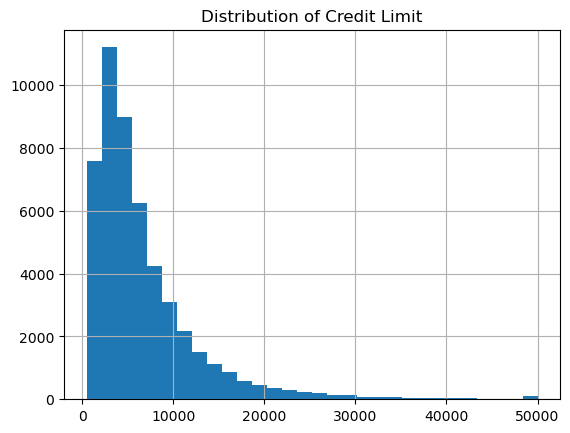

In [33]:
account_profiles_df["credit_limit"].hist(bins = 30)
plt.title("Distribution of Credit Limit")
plt.show()